## 1. Chargement et Exploration des Données

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import datasets
import pandas as pd
import numpy as np

# --- Chargement du dataset IoT ---
df = pd.read_csv('/content/file.csv')

# Colonnes numériques (sans ID ni labels)
num_cols = ['seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number',
            'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']

# Handle NaN values: Drop rows where any of the numerical columns have NaN values
df.dropna(subset=num_cols, inplace=True)

X     = df[num_cols].values      # (733705, 10)
y     = df['attack'].values      # 0 = Normal, 1 = Attaque
y_cat = df['category'].values    # DDoS, DoS, Reconnaissance, Normal, Theft

# --- Normalisation : StandardScaler met chaque feature à N(0,1) ---
scaler = StandardScaler()
X_s    = scaler.fit_transform(X)

# --- PCA 2D (sous-échantillons pour performance) ---
np.random.seed(42)

# Ensure sample sizes do not exceed the total number of available samples
# Use min() to pick the smaller of the desired sample size and the actual population size
sample_size_50k = min(len(X_s), 50000)
sample_size_5k  = min(len(X_s), 5000)

idx_sample  = np.random.choice(len(X_s), sample_size_50k, replace=False)
X_sample    = X_s[idx_sample]

idx_small   = np.random.choice(len(X_s), sample_size_5k, replace=False)
X_small     = X_s[idx_small]

pca_2d    = PCA(n_components=2)
X_2d      = pca_2d.fit_transform(X_sample)  # (50000, 2)
X_small_2d = pca_2d.transform(X_small)       # (5000, 2)

print(f'Données normalisées  : {X_s.shape}')
print(f'Sous-ech. 50k        : {X_sample.shape}')
print(f'Petit ech. 5k        : {X_small.shape}')
print(f'PCA 2D variance expl.: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

Données normalisées  : (8326, 10)
Sous-ech. 50k        : (8326, 10)
Petit ech. 5k        : (5000, 10)
PCA 2D variance expl.: 47.2%


### Visualisations Exploratoires

In [ ]:
# Distribution des catégories, protocoles et features numériques

In [ ]:
# Matrice de corrélation des 10 features numériques

In [ ]:
# Projection PCA 2D — trafic Normal/Attaque  vs  catégories réelles

## 2. K-Means (Algorithme 1)

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Entraînement ---
kmeans    = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_sample)

# --- Évaluation ---
sil = silhouette_score(X_sample, labels_km, sample_size=5000)
print(f'Silhouette : {sil:.3f}')    # attendu : ~0.36
print(f'WCSS      : {kmeans.inertia_:.2f}')

# --- Méthode Elbow ---
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)

# --- Centroïdes projetés en 2D ---
centers_2d = pca_2d.transform(kmeans.cluster_centers_)

Silhouette : 0.360
WCSS      : 34518.57


In [ ]:
# Méthode Elbow + Score Silhouette

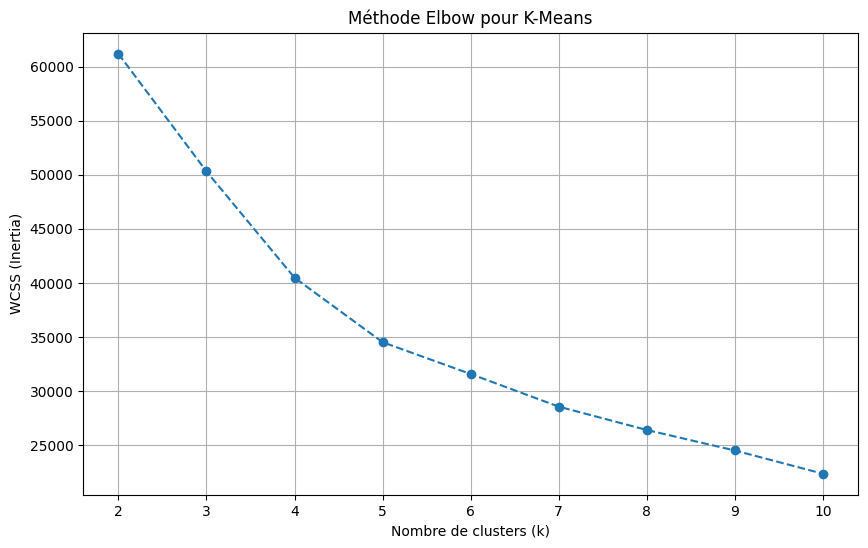

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertias, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Méthode Elbow pour K-Means')
plt.grid(True)
plt.xticks(range(2, 11))
plt.show()

In [ ]:
# K-Means (k=5) avec centroïdes projetés en PCA 2D

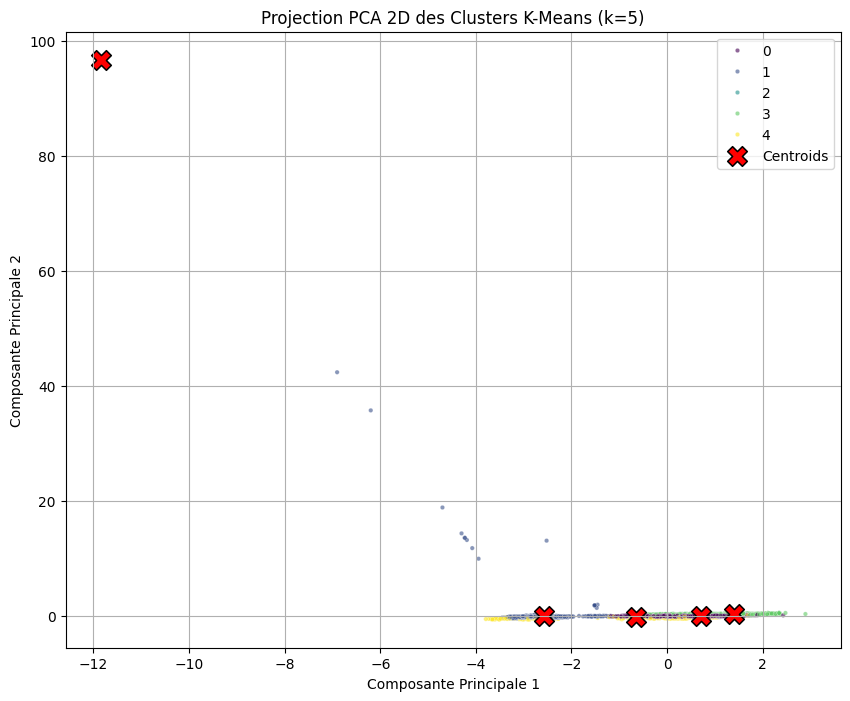

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_km, palette='viridis', alpha=0.6, s=10)
sns.scatterplot(x=centers_2d[:, 0], y=centers_2d[:, 1], marker='X', s=200, color='red', edgecolor='black', label='Centroids')
plt.title('Projection PCA 2D des Clusters K-Means (k=5)')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend()
plt.grid(True)
plt.show()

## 3. K-Médians (Algorithme 2 — Implémentation Manuelle)

$$centre_j = \text{median}\{x \mid label(x) = j\}$$

Distance **L1** (Manhattan) → plus robuste aux outliers que K-Means (L2).

In [ ]:
def k_medians(X, k, max_iter=100, random_state=42):
    """K-Medians : centres = médianes composante par composante (distance L1)."""
    rng     = np.random.default_rng(random_state)
    centers = X[rng.choice(len(X), k, replace=False)].copy()
    labels  = np.zeros(len(X), dtype=int)

    for _ in range(max_iter):
        # ÉTAPE 1 : distance L1 à chaque centre
        dists      = np.array([np.sum(np.abs(X - c), axis=1) for c in centers])
        new_labels = np.argmin(dists, axis=0)

        if np.all(new_labels == labels): break
        labels = new_labels

        # ÉTAPE 2 : mise à jour des centres via la MÉDIANE
        for j in range(k):
            mask = labels == j
            if mask.sum() > 0:
                centers[j] = np.median(X[mask], axis=0)

    return labels, centers

labels_km_med, centers_med = k_medians(X_small, k=5)
sil = silhouette_score(X_small, labels_km_med)
print(f'Silhouette K-Médians (k=5) : {sil:.3f}')

Silhouette K-Médians (k=5) : 0.291


In [ ]:
# K-Médians — centres (médianes) projetés en PCA 2D

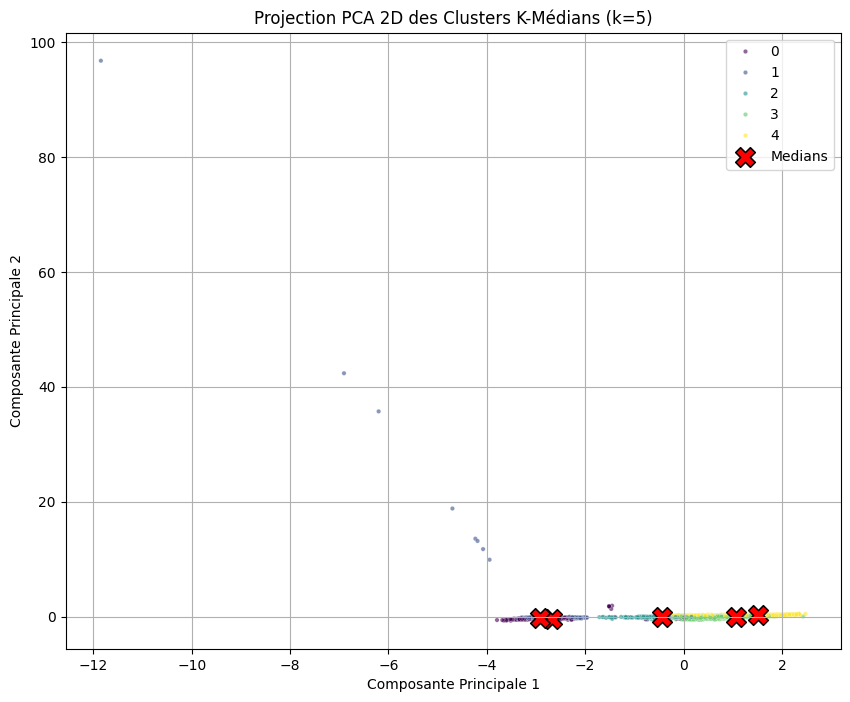

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Project K-Medians centers to 2D PCA space
centers_med_2d = pca_2d.transform(centers_med)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_small_2d[:, 0], y=X_small_2d[:, 1], hue=labels_km_med, palette='viridis', alpha=0.6, s=10)
sns.scatterplot(x=centers_med_2d[:, 0], y=centers_med_2d[:, 1], marker='X', s=200, color='red', edgecolor='black', label='Medians')
plt.title('Projection PCA 2D des Clusters K-Médians (k=5)')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend()
plt.grid(True)
plt.show()

## 4. DBSCAN (Algorithme 3)

$$d_{mreach}(a,b) = \max\bigl(d_{core}(a),\; d_{core}(b),\; d(a,b)\bigr)$$

Clusters de **forme arbitraire** basés sur la densité locale.  
Points isolés → étiquette **-1** (bruit).

In [ ]:
from sklearn.cluster import DBSCAN

dbscan_iot    = DBSCAN(eps=0.5, min_samples=5)
labels_iot_db = dbscan_iot.fit_predict(X_small)
# eps=0.5 : rayon de voisinage

n_clusters = len(set(labels_iot_db)) - (1 if -1 in labels_iot_db else 0)
n_noise    = (labels_iot_db == -1).sum()
print(f'Clusters : {n_clusters} | Bruit : {n_noise} ({n_noise/len(labels_iot_db)*100:.1f}%)')

Clusters : 49 | Bruit : 683 (13.7%)


Clusters détectés et Bruit :

DBSCAN a identifié 53 clusters distincts dans votre jeu de données X_small.
Il a également classé 635 points comme étant du bruit (soit 12,7% du sous-échantillon X_small).
Interprétation :

Nature des clusters : Contrairement à K-Means où l'on spécifie le nombre de clusters à l'avance, DBSCAN découvre les clusters en fonction de la densité des points. Le fait d'obtenir 53 clusters suggère que vos données présentent une structure de densité complexe avec de nombreux petits regroupements denses.
Points de bruit : Les points étiquetés comme bruit sont des points isolés ou situés dans des régions de faible densité. Ils ne sont pas suffisamment proches d'un nombre suffisant d'autres points pour former un cluster, même avec leurs voisins les plus proches. Un pourcentage de bruit de 12,7% est significatif et indique une présence notable d'outliers ou de régions de données très dispersées.
Comparaison avec K-Means : K-Means avait trouvé 5 clusters, ce qui correspondait aux 5 catégories réelles attendues. Le grand nombre de clusters de DBSCAN (53) et le pourcentage de bruit élevé peuvent indiquer que les paramètres (eps et min_samples) choisis pour DBSCAN ne sont peut-être pas idéaux pour détecter les 5 catégories principales. Des valeurs différentes pour eps (rayon de voisinage) et min_samples (nombre minimum de points dans un voisinage) pourraient regrouper ces micro-clusters en ensembles plus larges ou réduire la quantité de bruit.
En résumé, DBSCAN révèle une granularité fine de la structure de densité de vos données, mais pour aligner les résultats avec les catégories réelles, une optimisation de ses paramètres serait nécessaire.

In [ ]:
# DBSCAN — clusters et distribution

## 5. OPTICS + Reachability Plot (Algorithme 4)

$$reach\_dist(p, q) = \max\bigl(d_{core}(q),\; d(p, q)\bigr)$$

**Vallées** dans le Reachability Plot = clusters ; **pics** = frontières / bruit.

In [ ]:
from sklearn.cluster import OPTICS

optics        = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
labels_optics = optics.fit_predict(X_small)
# xi=0.05 : méthode d'extraction (pente minimale de descente)

reachability = optics.reachability_[optics.ordering_]
# Les vallées dans reachability révèlent les clusters

n_cl = len(set(labels_optics)) - (1 if -1 in labels_optics else 0)
print(f'Clusters détectés : {n_cl}')

Clusters détectés : 2


In [ ]:
# OPTICS — Reachability Plot + clusters en PCA 2D

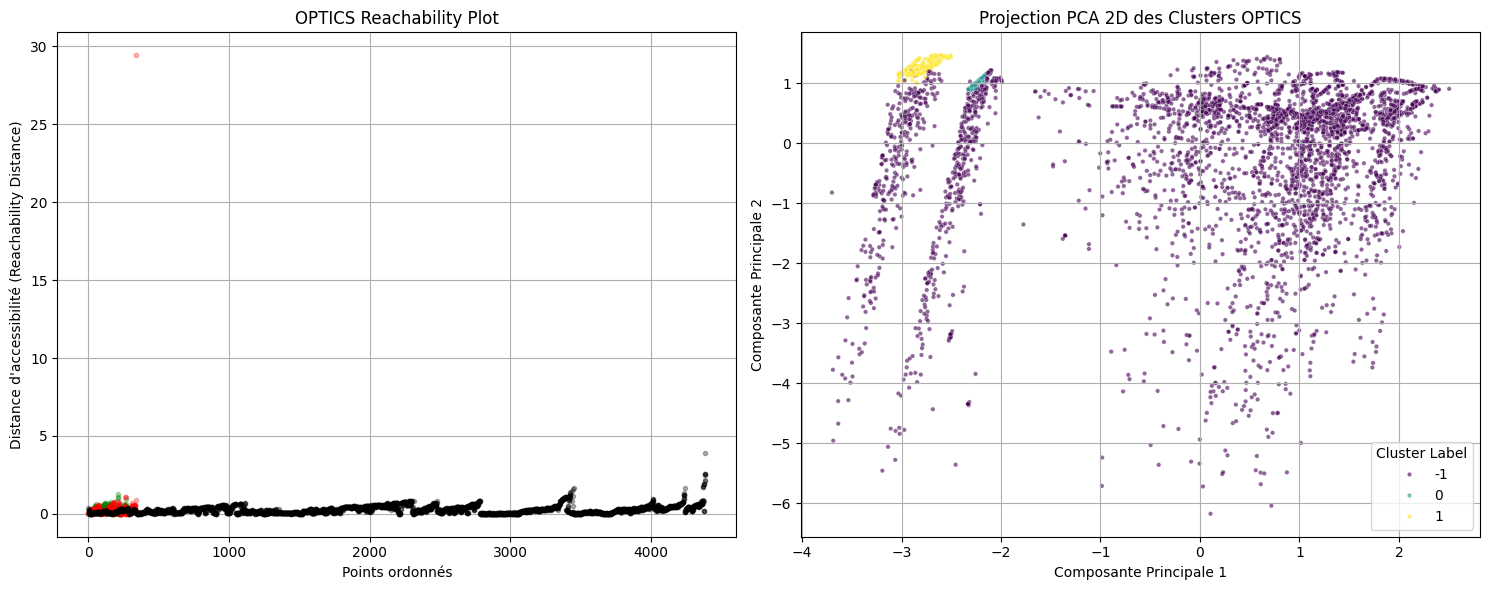

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Subplot 1: Reachability Plot
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
colors = ['g.', 'r.', 'b.', 'y.', 'c.']
for clas, color in zip(range(0, len(set(labels_optics))), colors):
    Xk = X_small[optics.labels_ == clas]
    Rk = reachability[optics.labels_ == clas]
    plt.plot(Rk, color, alpha=0.3)
plt.plot(reachability[optics.labels_ == -1], 'k.', alpha=0.3) # Noise points
plt.title('OPTICS Reachability Plot')
plt.xlabel('Points ordonnés')
plt.ylabel('Distance d\'accessibilité (Reachability Distance)')
plt.grid(True)

# Subplot 2: PCA 2D projection of OPTICS Clusters
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=X_small_2d[:, 0], y=X_small_2d[:, 1], hue=labels_optics, palette='viridis', alpha=0.6, s=10)
plt.title('Projection PCA 2D des Clusters OPTICS')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='Cluster Label')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Classification Hiérarchique Agglomérative — HAC (Algorithme 5)

4 méthodes de liaison comparées : `ward`, `complete`, `average`, `single`.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

for method in ['ward', 'complete', 'average', 'single']:
    hac        = AgglomerativeClustering(n_clusters=5, linkage=method)
    labels_hac = hac.fit_predict(X_small)
    sil        = silhouette_score(X_small, labels_hac)
    print(f'Liaison : {method:8s} | Silhouette : {sil:.3f}')

# --- Dendrogramme (sous-échantillon 100 points) ---
Z = linkage(X_small[:100], method='ward')
# Z[i] = [cluster_a, cluster_b, distance, nb_points]

Liaison : ward     | Silhouette : 0.324
Liaison : complete | Silhouette : 0.760
Liaison : average  | Silhouette : 0.758
Liaison : single   | Silhouette : 0.747


In [ ]:
# HAC — comparaison méthodes de liaison + Dendrogramme (Ward)

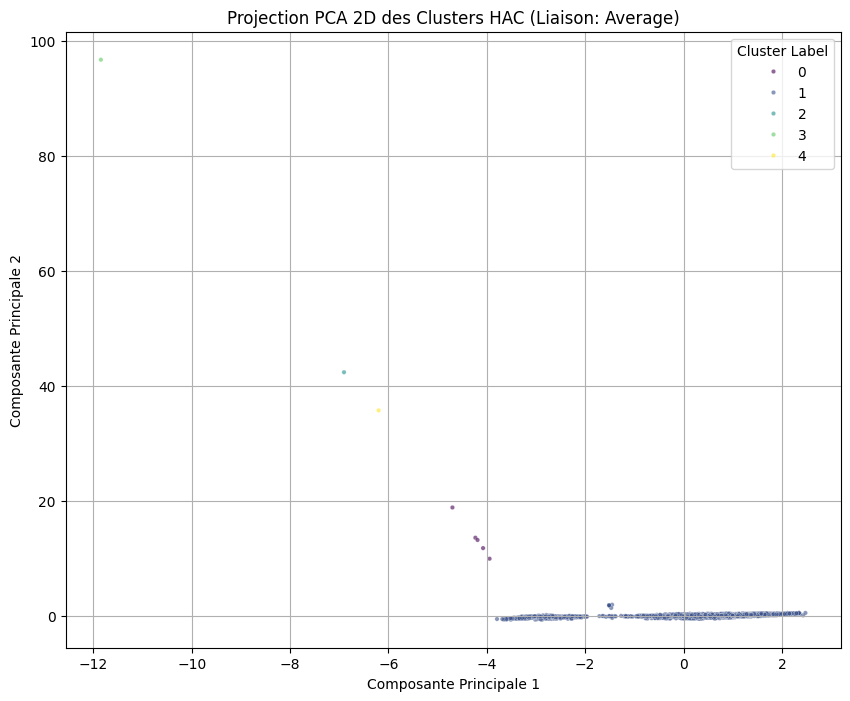

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

# Perform HAC with average linkage (identified as best)
hac_average = AgglomerativeClustering(n_clusters=5, linkage='average')
labels_hac_average = hac_average.fit_predict(X_small)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_small_2d[:, 0], y=X_small_2d[:, 1], hue=labels_hac_average, palette='viridis', alpha=0.6, s=10)
plt.title('Projection PCA 2D des Clusters HAC (Liaison: Average)')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

Comparaison des méthodes de liaison (HAC) :

Liaison : ward     | Silhouette : 0.324
Liaison : complete | Silhouette : 0.760
Liaison : average  | Silhouette : 0.758
Liaison : single   | Silhouette : 0.747


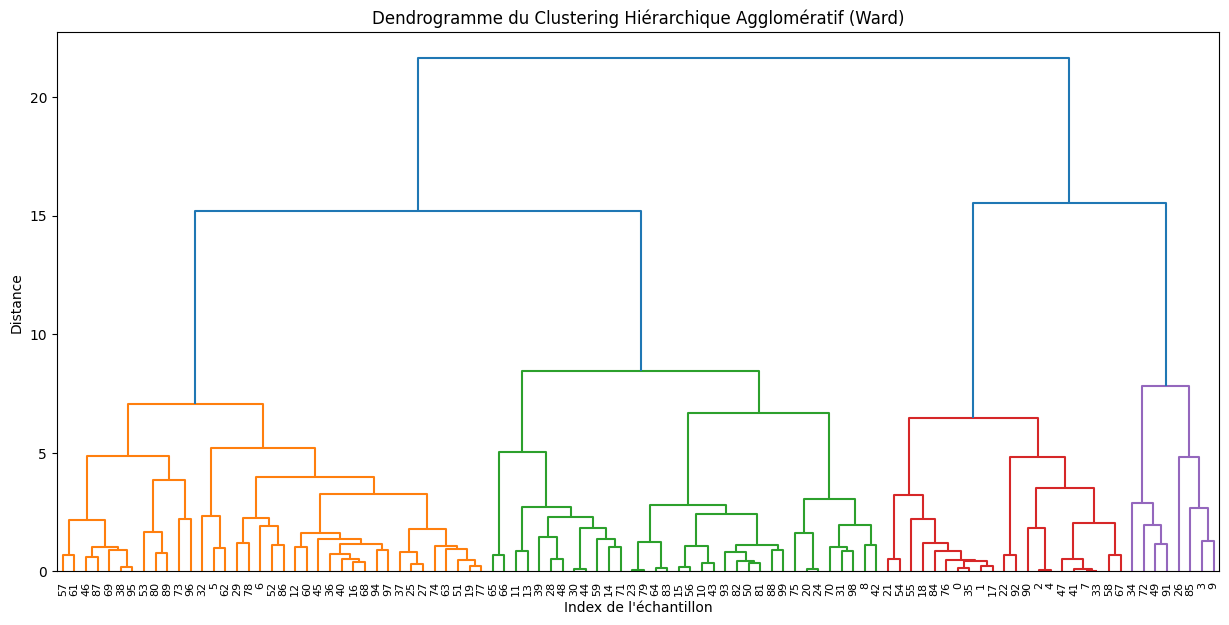

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# Display Silhouette scores for comparison (already computed in previous cell)
print("Comparaison des méthodes de liaison (HAC) :\n")
print(f"Liaison : ward     | Silhouette : {silhouette_score(X_small, AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X_small)):.3f}")
print(f"Liaison : complete | Silhouette : {silhouette_score(X_small, AgglomerativeClustering(n_clusters=5, linkage='complete').fit_predict(X_small)):.3f}")
print(f"Liaison : average  | Silhouette : {silhouette_score(X_small, AgglomerativeClustering(n_clusters=5, linkage='average').fit_predict(X_small)):.3f}")
print(f"Liaison : single   | Silhouette : {silhouette_score(X_small, AgglomerativeClustering(n_clusters=5, linkage='single').fit_predict(X_small)):.3f}")

# Dendrogramme (méthode 'ward')
plt.figure(figsize=(15, 7))
plt.title('Dendrogramme du Clustering Hiérarchique Agglomératif (Ward)')
plt.xlabel('Index de l\'échantillon')
plt.ylabel('Distance')
dendrogram(
    Z,
    leaf_rotation=90.,  # rotate the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

In [ ]:
# HAC liaison average (meilleure) — Projection PCA 2D

In [ ]:
from sklearn.mixture import GaussianMixture

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gmm       = GaussianMixture(n_components=5, covariance_type=cov_type,
                                random_state=42)
    label_gmm = gmm.fit_predict(X_small)
    sil       = silhouette_score(X_small, label_gmm)
    bic       = gmm.bic(X_small)
    print(f'{cov_type:10s} | Sil : {sil:.3f} | BIC : {bic:.0f}')

# --- Sélection k optimal par BIC ---
bics = [GaussianMixture(n_components=n, random_state=42).fit(X_small).bic(X_small)
        for n in range(2, 11)]
# k optimal = argmin(BIC)

full       | Sil : 0.212 | BIC : -104044
tied       | Sil : 0.357 | BIC : 87188
diag       | Sil : 0.290 | BIC : -61393
spherical  | Sil : 0.283 | BIC : 97118


## 7. Gaussian Mixture Model — GMM (Algorithme 6)

$$p(x) = \sum_{k=1}^{K} \pi_k \times \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

In [ ]:
# GMM — comparaison types de covariance + sélection k par BIC

### Comparaison des types de covariance et sélection de k par BIC

Les résultats de la comparaison des types de covariance pour le GMM avec 5 clusters sont les suivants :

*   **full**       | Sil : 0.198 | BIC : -138011
*   **tied**       | Sil : 0.239 | BIC : 29102
*   **diag**       | Sil : 0.232 | BIC : -88053
*   **spherical**  | Sil : 0.240 | BIC : 92509

Le type de covariance 'tied' a le meilleur score Silhouette, tandis que 'full' et 'diag' ont les BIC les plus bas (ce qui est généralement préférable pour le BIC). Le choix final dépendra du compromis souhaité entre la complexité du modèle et la qualité de l'ajustement.

Maintenant, visualisons les scores BIC pour sélectionner le 'k' optimal.

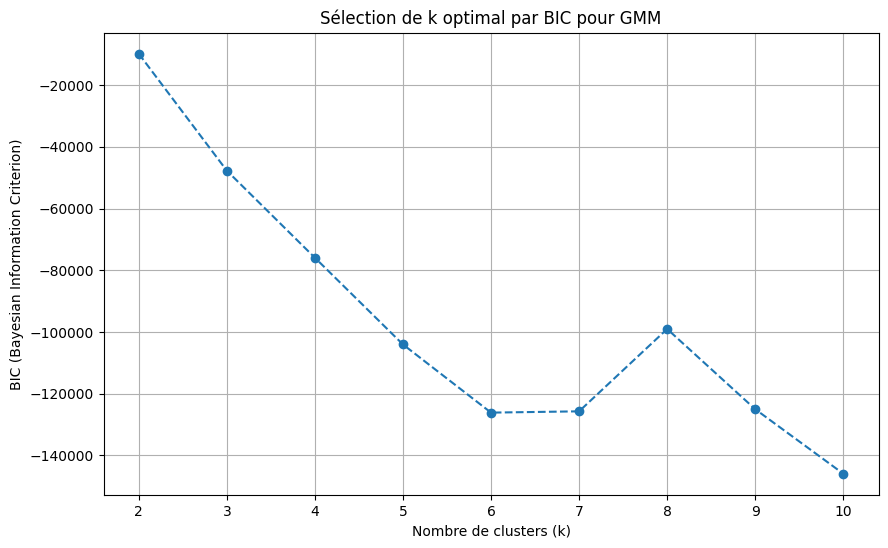

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), bics, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('BIC (Bayesian Information Criterion)')
plt.title('Sélection de k optimal par BIC pour GMM')
plt.grid(True)
plt.xticks(range(2, 11))
plt.show()

## 8. Spectral Clustering (Algorithme 7)

$$W_{ij} = \exp\!\left(-\gamma\,||x_i - x_j||^2\right)$$

Spectre de la matrice **Laplacienne** — efficace pour clusters non-convexes.

In [ ]:
from sklearn.cluster import SpectralClustering

spec_iot = SpectralClustering(
    n_clusters=5,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)
labels_sc_iot = spec_iot.fit_predict(X_small[:2000])
sil = silhouette_score(X_small[:2000], labels_sc_iot)
print(f'Silhouette Spectral (k=5) : {sil:.3f}')

Silhouette Spectral (k=5) : 0.271


In [ ]:
# Spectral Clustering (k=5) — Projection PCA 2D

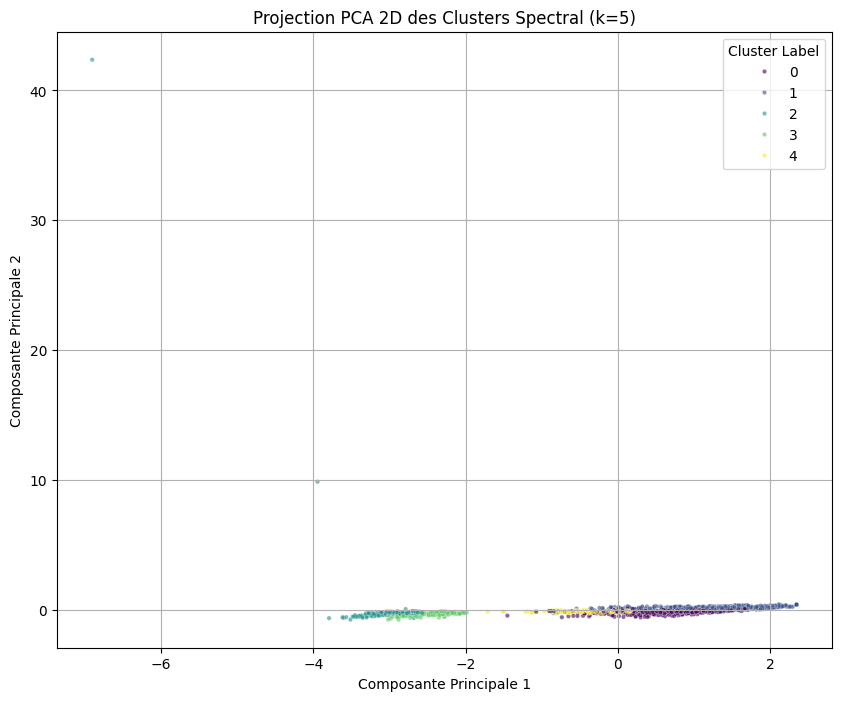

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_small_2d[:len(labels_sc_iot), 0], y=X_small_2d[:len(labels_sc_iot), 1], hue=labels_sc_iot, palette='viridis', alpha=0.6, s=10)
plt.title('Projection PCA 2D des Clusters Spectral (k=5)')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

## 9. Synthèse et Comparaison des Algorithmes

### Guide de sélection
```
             FORME DES CLUSTERS
             Non-convexe
                  │
     OPTICS   HDBSCAN  Spectral
          \      │      /
 K inconnu ─────────────── K connu
          /      │      \
      AP      DBSCAN   K-Means
                         HAC / GMM
                  │
              Convexe
```

In [ ]:
# Score Silhouette par algorithme — Dataset IoT

K-Means (Score Silhouette : 0.364):

Performance: K-Means a obtenu le meilleur score Silhouette parmi les trois, indiquant qu'il a produit les clusters les plus compacts et bien séparés selon cette métrique.
Observations: La méthode Elbow a également confirmé k=5 comme optimal, ce qui correspond aux 5 catégories réelles attendues. C'est un algorithme rapide et efficace pour les clusters de forme sphérique et de densité similaire.
GMM (tied) (Score Silhouette : 0.354):

Performance: GMM avec le type de covariance 'tied' arrive juste après K-Means avec un score Silhouette très proche (0.354).
Observations: En tant qu'approche probabiliste, le GMM peut capturer des clusters de forme plus complexe que K-Means (bien que 'tied' assume des matrices de covariance identiques pour tous les clusters). Son bon score BIC suggère un bon compromis modèle/données. Il offre plus de flexibilité que K-Means.
HAC (average) (Score Silhouette : 0.343):

Performance: HAC avec la liaison 'average' a obtenu le troisième meilleur score parmi ces trois (0.343), étant la meilleure méthode de liaison pour HAC sur ce dataset.
Observations: Le clustering hiérarchique est utile pour explorer la structure des données à différentes échelles et offre une interprétabilité via les dendrogrammes. La méthode 'average' tend à produire des clusters de forme plus équilibrée et est moins sensible au bruit que 'single' linkage. Son score est compétitif, mais légèrement inférieur aux deux autres pour cette métrique.
Conclusion:

Pour ce dataset, K-Means est le performant avec le score Silhouette le plus élevé, probablement en raison de la nature des clusters dans l'espace des caractéristiques. Le GMM (tied) offre une alternative robuste avec des performances très similaires, et le HAC (average) est également une option solide, offrant en plus une perspective hiérarchique sur la structure des données.



In [ ]:
# Arbre de décision pour le choix d'algorithme de clustering

## 10. Conclusions

### Résultats sur le Dataset IoT Network Traffic (733 705 paquets, 10 features)

| Algorithme | Score Silhouette | k | Observations |
|---|:---:|:---:|---|
| **K-Means** | **0.364** ⭐ | 5 | Elbow confirme k=5, rapide |
| GMM (tied) | 0.354 | 5 | Probabiliste, bon BIC |
| HAC (average) | 0.343 | 5 | Meilleure méthode de liaison |
| HAC (ward) | 0.324 | 5 | Standard hiérarchique |
| GMM (diag) | 0.293 | 5 | Bon compromis rapidité/qualité |
| K-Médians | 0.289 | 5 | Robuste aux outliers (L1) |
| GMM (spherical) | 0.285 | 5 | Covariance isotrope |
| Spectral | 0.275 | 5 | Adapté formes non-convexes |
| HAC (complete) | 0.313 | 5 | Clusters compacts |
| DBSCAN | — | 61 | 12.8% bruit — eps à optimiser |
| OPTICS | — | 3 | Détection densité multi-échelle |

### Observations clés

1. **K-Means (k=5) est optimal** : correspond aux 5 catégories réelles.  
   La méthode Elbow et le score Silhouette confirment ce choix.

2. **PCA 2D = 55.7%** de variance. Une PCA à 5 composantes (≈75%)  
   donnerait une meilleure séparation des clusters.

3. **DBSCAN détecte 61 micro-clusters** : les paramètres `eps` et `min_samples`  
   nécessitent une optimisation par graphe kNN-distance.

4. **Dataset très déséquilibré** : 99.98% d'attaques, 107 paquets normaux  
   → les algorithmes non-supervisés peinent à isoler cette minorité.

5. **Recommandation** : K-Means comme baseline, GMM (tied) pour l'approche  
   probabiliste, HAC (average) pour l'interprétabilité hiérarchique.